In [1]:
%cd /capstor/scratch/cscs/mkariuki

/capstor/scratch/cscs/mkariuki


In [2]:
# importing the libraries
from datasets import load_dataset
import matplotlib.pyplot as plt
from datasets import load_from_disk
import numpy as np
import torch
from transformers  import WhisperTokenizer
from transformers  import WhisperFeatureExtractor
from transformers import WhisperForConditionalGeneration
import os
import shutil
from IPython.display import Audio
from datasets import Audio
from huggingface_hub import list_repo_files
from datasets import Audio
from transformers import WhisperProcessor
from transformers.models.whisper.english_normalizer import BasicTextNormalizer
from dataclasses import dataclass
from typing import Any, Dict, List, Union
import evaluate
from transformers import Seq2SeqTrainingArguments
from transformers import TrainerCallback
from transformers.trainer_pt_utils import IterableDatasetShard
from torch.utils.data import IterableDataset
from transformers import Seq2SeqTrainer

In [3]:
import os
os.environ["NCCL_P2P_DISABLE"] = "1"
os.environ["NCCL_IB_DISABLE"] = "1"

In [ ]:
# downloading a subset of the train  dataset
train_files = [f"train/scripted/audios/train_scripted_{str(i).zfill(3)}.parquet" for i in range(15, 30)]
full_train = load_dataset("Anv-ke/kikuyu", data_files=train_files, split="train")

In [7]:
len(full_train)

28465

In [10]:
#downloading validation subset data
val_files = [f"dev/scripted/audios/dev_scripted_{str(i).zfill(3)}.parquet" for i in range(2, 4)]
full_val = load_dataset("Anv-ke/kikuyu", data_files=val_files, split="train")

dev/scripted/audios/dev_scripted_002.par(…):   0%|          | 0.00/757M [00:00<?, ?B/s]

dev/scripted/audios/dev_scripted_003.par(…):   0%|          | 0.00/313M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

In [11]:
len(full_val)

2681

In [12]:
#downloading test subset data
test_files = [f"dev_test/scripted/audios/dev_test_scripted_{str(i).zfill(3)}.parquet" for i in range(2, 4)]
full_test = load_dataset("Anv-ke/kikuyu", data_files=test_files, split="train")

dev_test/scripted/audios/dev_test_script(…):   0%|          | 0.00/747M [00:00<?, ?B/s]

dev_test/scripted/audios/dev_test_script(…):   0%|          | 0.00/262M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

In [13]:
len(full_test)

2766

In [19]:
base_dir = "kikuyu_dataset"

# Create the main directory and sub-directories if they don't exist
os.makedirs(os.path.join(base_dir, "train"), exist_ok=True)
os.makedirs(os.path.join(base_dir, "validation"), exist_ok=True)
os.makedirs(os.path.join(base_dir, "test"), exist_ok=True)

# Now save the datasets you downloaded
print("Saving Train...")
full_train.save_to_disk(os.path.join(base_dir, "train"))
print("Saving Validation...")
full_val.save_to_disk(os.path.join(base_dir, "validation"))
print("Saving Test...")
full_test.save_to_disk(os.path.join(base_dir, "test"))

print("Done! All data is stored in the 'kikuyu_dataset' folder.")

Saving Train...


Saving the dataset (0/23 shards):   0%|          | 0/21166 [00:00<?, ? examples/s]

Saving Validation...


Saving the dataset (0/4 shards):   0%|          | 0/4143 [00:00<?, ? examples/s]

Saving Test...


Saving the dataset (0/4 shards):   0%|          | 0/3756 [00:00<?, ? examples/s]

Done! All data is stored in the 'kikuyu_dataset' folder.


In [20]:
# data analysis

def check_corrupted_files(dataset_name, dataset_path):
    print(f"\n--- Checking {dataset_name} split ---")
    ds = load_from_disk(dataset_path)
    
    corrupted_indices = []
    
    # We use a simple loop. For very large datasets, 
    # you'd use .map(), but a loop is clearer for debugging.
    for i in range(len(ds)):
        try:
            # Try to access the audio array
            audio_array = ds[i]["audio"]["array"]
            
            # Check if the audio is empty (silence/zero length)
            if audio_array is None or len(audio_array) == 0:
                print(f"Index {i}: Empty audio data.")
                corrupted_indices.append(i)
                
        except Exception as e:
            print(f"Index {i}: Failed to load. Error: {e}")
            corrupted_indices.append(i)
            
    if not corrupted_indices:
        print(f"✅ Success! No corrupted files found in {dataset_name}.")
    else:
        print(f"⚠️ Found {len(corrupted_indices)} issues in {dataset_name}.")
        
    return corrupted_indices




In [21]:
# Run the check on your saved folders
bad_train = check_corrupted_files("Train", "./kikuyu_dataset/train")
bad_val   = check_corrupted_files("Validation", "./kikuyu_dataset/validation")
bad_test  = check_corrupted_files("Test", "./kikuyu_dataset/test")


--- Checking Train split ---


Loading dataset from disk:   0%|          | 0/23 [00:00<?, ?it/s]

Index 9107: Failed to load. Error: Error opening <_io.BytesIO object at 0x40022bec48b0>: Format not recognised.
Index 16317: Failed to load. Error: Error opening <_io.BytesIO object at 0x40022bec4c20>: Format not recognised.
Index 18151: Failed to load. Error: Error opening <_io.BytesIO object at 0x40022bec48b0>: Format not recognised.
Index 18156: Failed to load. Error: Error opening <_io.BytesIO object at 0x4002a7e03dd0>: Format not recognised.
Index 18163: Failed to load. Error: Error opening <_io.BytesIO object at 0x40022bec4c20>: Format not recognised.
⚠️ Found 5 issues in Train.

--- Checking Validation split ---
Index 136: Failed to load. Error: Error opening <_io.BytesIO object at 0x4002a7e3f920>: Format not recognised.
Index 146: Failed to load. Error: Error opening <_io.BytesIO object at 0x4002a7e3df80>: Format not recognised.
Index 162: Failed to load. Error: Error opening <_io.BytesIO object at 0x4002a7e3f9c0>: Format not recognised.
Index 184: Failed to load. Error: Error 

In [26]:
def diagnose_final_attempt(dataset_path, index):
    print(f"\n--- Investigating Row {index} ---")
    ds = load_from_disk(dataset_path)
    
    # Accessing  the raw Arrow table to avoid any Decoding or Casting
    table = ds.data
    raw_row = table.slice(index, 1).to_pydict()
    audio_data = raw_row['audio'][0]
    
    if audio_data is None:
        print("Result: The entire audio column for this row is NULL.")
        return
    raw_bytes = audio_data.get('bytes')
    
    if raw_bytes is None:
        print("Result: Dictionary exists but 'bytes' key is missing or empty.")
        print(f"Available keys in audio dict: {list(audio_data.keys())}")
    else:
        byte_len = len(raw_bytes)
        print(f"Size on disk: {byte_len} bytes")
        
        # Checking the first 12 bytes for a 'Signature'
        signature = raw_bytes[:12]
        print(f"Hex Signature: {signature.hex(' ')}")
        print(f"ASCII Signature: {signature}")

        if byte_len < 500:
            print("Conclusion: File is too small. This is a corrupted stub.")
        elif b'RIFF' not in signature[:4]:
            print("Conclusion: Header Mismatch. The data is not a valid WAV file.")

# checking  corrupted  files in a train index
diagnose_final_attempt("./kikuyu_dataset/train", 9107)


--- Investigating Row 9107 ---


Loading dataset from disk:   0%|          | 0/23 [00:00<?, ?it/s]

Size on disk: 319932 bytes
Hex Signature: 55 6b 6c 47 52 6b 53 70 41 77 42 58
ASCII Signature: b'UklGRkSpAwBX'
Conclusion: Header Mismatch. The data is not a valid WAV file.


In [27]:
def filter_and_replace(name, bad_indices, path):
    print(f"--- Cleaning {name} ---")
    
    # 1. Load the current version
    ds = load_from_disk(path)
    total_before = len(ds)
    good_indices = [i for i in range(total_before) if i not in bad_indices]

    clean_ds = ds.select(good_indices)
    clean_path = f"{path}_clean"
    clean_ds.save_to_disk(clean_path)
    print(f"Done: Removed {len(bad_indices)} files. New total: {len(clean_ds)}")
    return clean_path

# Executing  the cleaning phase
clean_train_path = filter_and_replace("Train", bad_train, "./kikuyu_dataset/train")
clean_val_path   = filter_and_replace("Validation", bad_val, "./kikuyu_dataset/validation")
clean_test_path  = filter_and_replace("Test", bad_test, "./kikuyu_dataset/test")

--- Cleaning Train ---


Loading dataset from disk:   0%|          | 0/23 [00:00<?, ?it/s]

Saving the dataset (0/23 shards):   0%|          | 0/21161 [00:00<?, ? examples/s]

Done: Removed 5 files. New total: 21161
--- Cleaning Validation ---


Saving the dataset (0/4 shards):   0%|          | 0/4108 [00:00<?, ? examples/s]

Done: Removed 35 files. New total: 4108
--- Cleaning Test ---


Saving the dataset (0/4 shards):   0%|          | 0/3748 [00:00<?, ? examples/s]

Done: Removed 8 files. New total: 3748


In [29]:
# Listing the original corrupted folders
original_folders = ["./kikuyu_dataset/train", "./kikuyu_dataset/validation", "./kikuyu_dataset/test"]

for folder in original_folders:
    if os.path.exists(folder):
        shutil.rmtree(folder) 
        print(f"Deleted corrupted folder: {folder}")

#  Renaming  data to the original names
os.rename("./kikuyu_dataset/train_clean", "./kikuyu_dataset/train")
os.rename("./kikuyu_dataset/validation_clean", "./kikuyu_dataset/validation")
os.rename("./kikuyu_dataset/test_clean", "./kikuyu_dataset/test")

In [5]:
# Loading datasets from the disk
train_ds = load_from_disk("./Combined_ANV_dataset/train")
val_ds   = load_from_disk("./Combined_ANV_dataset/validation")
test_ds  = load_from_disk("./Combined_ANV_dataset/test")

print(f"Train: {len(train_ds)} rows") 
print(f"Val:   {len(val_ds)} rows")
print(f"Test:  {len(test_ds)} rows")

Loading dataset from disk:   0%|          | 0/46 [00:00<?, ?it/s]

Train: 49591 rows
Val:   6789 rows
Test:  6514 rows


In [6]:
def calculate_total_hours(dataset):
    # Calculate duration for each sample: length of array / sampling_rate
    # This might take a minute for 21k rows
    total_seconds = sum(len(x["array"]) / x["sampling_rate"] for x in dataset["audio"])
    return total_seconds / 3600

print(f"Train Duration: {calculate_total_hours(train_ds):.2f} hours")
print(f"Val Duration:   {calculate_total_hours(val_ds):.2f} hours")

Train Duration: 71.74 hours
Val Duration:   8.39 hours


In [32]:
#checking the sampling rate for the first audio
def check_sampling_rate(dataset, name):
    sr = dataset[0]["audio"]["sampling_rate"]
    print(f"{name} Sampling Rate: {sr} Hz")
    return sr

train_sr = check_sampling_rate(train_ds, "Train")
val_sr   = check_sampling_rate(val_ds, "Validation")
test_sr  = check_sampling_rate(test_ds, "Test")

Train Sampling Rate: 44100 Hz
Validation Sampling Rate: 44100 Hz
Test Sampling Rate: 44100 Hz


In [7]:
#resampling to the standard  sampling rate 16khz
train_ds = train_ds.cast_column("audio", Audio(sampling_rate=16000))
val_ds   = val_ds.cast_column("audio", Audio(sampling_rate=16000))
test_ds  = test_ds.cast_column("audio", Audio(sampling_rate=16000))
print(f"New Sampling Rate: {train_ds[0]['audio']['sampling_rate']} Hz")

New Sampling Rate: 16000 Hz


In [8]:
#getting the features
train_ds.features

{'audio': Audio(sampling_rate=16000, mono=True, decode=True, id=None),
 'filename': Value(dtype='string', id=None),
 'type': Value(dtype='string', id=None),
 'split': Value(dtype='string', id=None),
 'recorder_uuid': Value(dtype='string', id=None),
 'domain': Value(dtype='string', id=None),
 'transcription': Value(dtype='string', id=None),
 'language': Value(dtype='string', id=None)}

In [9]:
#droping  unnecesary columns
columns_to_remove = ["filename", "type", "split", "recorder_uuid", "domain", "language"]

# Applying  to each split
train_ds = train_ds.remove_columns(columns_to_remove)
val_ds   = val_ds.remove_columns(columns_to_remove)
test_ds  = test_ds.remove_columns(columns_to_remove)
print(" Features:", train_ds.features.keys())

 Features: dict_keys(['audio', 'transcription'])


In [10]:
#tokenizer = WhisperTokenizer.from_pretrained("openai/whisper-tiny", task="transcribe")

In [11]:
#calling the tokenizer and the feature extractor
processor = WhisperProcessor.from_pretrained("openai/whisper-tiny",  task="transcribe")

In [12]:
#normalizing data
do_lower_case = False
do_remove_punctuation = False

normalizer = BasicTextNormalizer()

In [13]:
def prepare_dataset(batch):
    # load and (possibly) resample audio data to 16kHz
    audio = batch["audio"]

    # compute log-Mel input features from input audio array 
    batch["input_features"] = processor.feature_extractor(audio["array"], sampling_rate=audio["sampling_rate"]).input_features[0]
    # compute input length of audio sample in seconds
    batch["input_length"] = len(audio["array"]) / audio["sampling_rate"]
    
    # optional pre-processing steps
    transcription = batch["transcription"]
    if do_lower_case:
        transcription = transcription.lower()
    if do_remove_punctuation:
        transcription = normalizer(transcription).strip()
    
    # encode target text to label ids
    batch["labels"] = processor.tokenizer(transcription).input_ids
    return batch


# def prepare_dataset(examples):
#     # compute log-Mel input features from input audio array 
#     audio = examples["audio"]
#     examples["input_features"] = feature_extractor(
#         audio["array"], sampling_rate=16000).input_features[0]
#     del examples["audio"]
#     transcription = examples["transcription"]

#     # encode target text to label ids 
#     examples["labels"] = tokenizer(transcription).input_ids
#     del examples["transcription"]
#     return examples

In [14]:
#mapping the train data
train_ds = train_ds.map(prepare_dataset, num_proc=4)

In [15]:
train_ds.set_format(type="torch", columns=["input_features", "labels"])

In [16]:
val_ds = val_ds.map(prepare_dataset, num_proc=4)
val_ds.set_format(type="torch", columns=["input_features", "labels"])

In [41]:
max_input_length = 15.0

def is_audio_in_length_range(length):
    return length < max_input_length

In [44]:
train_ds= train_ds.filter(
    is_audio_in_length_range,
    input_columns=["input_length"],
)

In [17]:
import torch

from dataclasses import dataclass
from typing import Any, Dict, List, Union

@dataclass
class DataCollatorSpeechSeq2SeqWithPadding:
    processor: Any

    def __call__(self, features: List[Dict[str, Union[List[int], torch.Tensor]]]) -> Dict[str, torch.Tensor]:
        # spliting inputs and labels since they have to be of different lengths and need different padding methods
        input_features = [{"input_features": feature["input_features"]} for feature in features]
        batch = self.processor.feature_extractor.pad(input_features, return_tensors="pt")

        # geting the tokenized label sequences
        label_features = [{"input_ids": feature["labels"]} for feature in features]
        # pad the labels to max length
        labels_batch = self.processor.tokenizer.pad(label_features, return_tensors="pt")

        # replacing padding with -100 to ignore loss correctly
        labels = labels_batch["input_ids"].masked_fill(labels_batch.attention_mask.ne(1), -100)

        # if bos token is appended in previous tokenization step,
        # cut bos token here as it's append later anyways
        if (labels[:, 0] == self.processor.tokenizer.bos_token_id).all().cpu().item():
            labels = labels[:, 1:]

        batch["labels"] = labels

        return batch

In [18]:
data_collator = DataCollatorSpeechSeq2SeqWithPadding(processor=processor)

In [19]:
#evaluation metrics
metric_wer = evaluate.load("wer")
metric_cer = evaluate.load("cer")

In [20]:
# # evaluate with the 'normalised' WER
# do_normalize_eval = True

# def compute_metrics(pred):
#     pred_ids = pred.predictions
#     label_ids = pred.label_ids

#     # replace -100 with the pad_token_id
#     label_ids[label_ids == -100] = processor.tokenizer.pad_token_id

#     # we do not want to group tokens when computing the metrics
#     pred_str = processor.tokenizer.batch_decode(pred_ids, skip_special_tokens=True)
#     label_str = processor.tokenizer.batch_decode(label_ids, skip_special_tokens=True)

#     if do_normalize_eval:
#         pred_str = [normalizer(pred) for pred in pred_str]
#         label_str = [normalizer(label) for label in label_str]

#     wer = 100 * metric.compute(predictions=pred_str, references=label_str)

#     return {"wer": wer}

do_normalize_eval = True
def compute_metrics(pred):
    pred_ids = pred.predictions
    label_ids = pred.label_ids

    # Replace -100 with the pad_token_id
    label_ids[label_ids == -100] = processor.tokenizer.pad_token_id

    # Decode predictions and labels
    pred_str = processor.tokenizer.batch_decode(pred_ids, skip_special_tokens=True)
    label_str = processor.tokenizer.batch_decode(label_ids, skip_special_tokens=True)

    # Normalize if requested
    if do_normalize_eval:
        pred_str = [normalizer(pred) for pred in pred_str]
        label_str = [normalizer(label) for label in label_str]

    # Compute both metrics
    wer = 100 * metric_wer.compute(predictions=pred_str, references=label_str)
    cer = 100 * metric_cer.compute(predictions=pred_str, references=label_str)

    return {"wer": wer, "cer": cer}


In [21]:
#loading the model
model = WhisperForConditionalGeneration.from_pretrained("openai/whisper-tiny")

In [22]:
model.config.forced_decoder_ids = None
model.config.suppress_tokens = []
model.config.use_cache = False

In [23]:
# defining training arguments
training_args = Seq2SeqTrainingArguments(
    output_dir="./",
    per_device_train_batch_size=64,
    gradient_accumulation_steps=1, 
    learning_rate=1e-5,
    warmup_steps=500,
    max_steps=1500,
    gradient_checkpointing=False,
    fp16=True,
    evaluation_strategy="steps",
    per_device_eval_batch_size=8,
    predict_with_generate=True,
    generation_max_length=225,
    save_steps=1000,
    eval_steps=200,
    logging_steps=25,
    report_to=["tensorboard"],
    load_best_model_at_end=True,
    metric_for_best_model="wer",
    dataloader_num_workers=8,
    greater_is_better=False,
    remove_unused_columns=False,
    push_to_hub=True,
)

/users/mkariuki/miniconda3/envs/lenv/lib/python3.12/site-packages/transformers/training_args.py:1611: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [24]:
trainer = Seq2SeqTrainer(
    args=training_args,
    model=model,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    tokenizer=processor,
    
)

/tmp/ipykernel_80560/2391572708.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(


In [25]:
processor.save_pretrained(training_args.output_dir)

[]

In [26]:
#calling the trainer API
trainer.train()

/users/mkariuki/miniconda3/envs/lenv/lib/python3.12/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Step,Training Loss,Validation Loss,Wer,Cer
200,1.173500,1.062414,90.777114,35.807545
400,0.715700,0.696632,62.687569,23.310166
600,0.569400,0.592113,51.939734,18.747940
800,0.500300,0.549826,48.891363,18.606143
1000,0.460100,0.527498,48.217336,18.207214
1200,0.449500,0.516708,49.516591,19.761990
1400,0.440700,0.510588,48.494876,19.522083


Due to a bug fix in https://github.com/huggingface/transformers/pull/28687 transcription using a multilingual Whisper will default to language detection followed by transcription instead of translation to English.This might be a breaking change for your use case. If you want to instead always translate your audio to English, make sure to pass `language='en'`.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
/users/mkariuki/miniconda3/envs/lenv/lib/python3.12/site-packages/transformers/modeling_utils.py:3353: UserWarning: Moving the following attributes in the config to the generation config: {'max_length': 448, 'suppress_tokens': [], 'begin_suppress_tokens': [220, 50257]}. You are seeing this warning because you've set generation parameters in the model config, as opposed to in the generation config.
  warnin

TrainOutput(global_step=1500, training_loss=0.8917794723510742, metrics={'train_runtime': 6178.0243, 'train_samples_per_second': 62.156, 'train_steps_per_second': 0.243, 'total_flos': 9.44107163578368e+18, 'train_loss': 0.8917794723510742, 'epoch': 7.731958762886598})

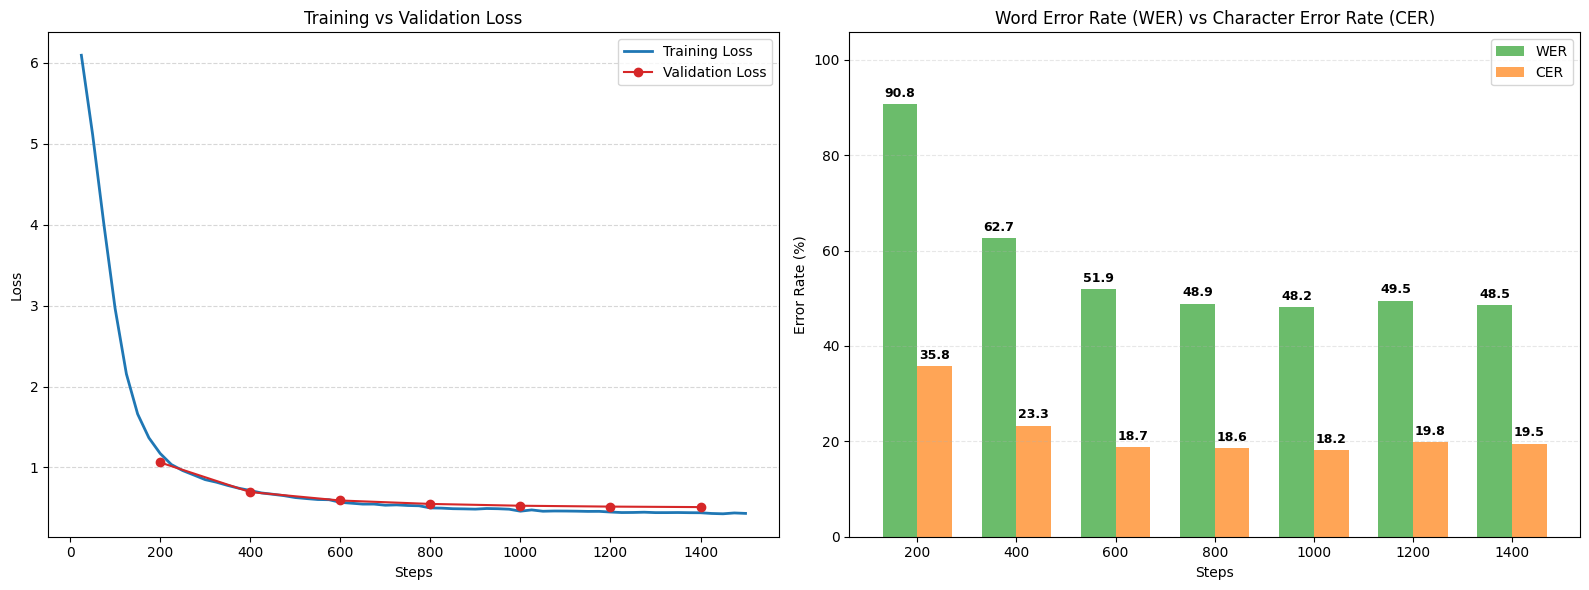

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Extracting logs 
history = trainer.state.log_history

train_loss, train_steps = [], []
eval_loss, eval_steps = [], []
eval_wer, eval_cer = [], []

for entry in history:
    if "loss" in entry:
        train_loss.append(entry["loss"])
        train_steps.append(entry["step"])
    if "eval_loss" in entry:
        eval_loss.append(entry["eval_loss"])
        eval_steps.append(entry["step"])
        eval_wer.append(entry.get("eval_wer", 0))
        eval_cer.append(entry.get("eval_cer", 0)) # Extract CER

# 2. Plotting
plt.figure(figsize=(16, 6))

# Subplot 1: Loss Curves
plt.subplot(1, 2, 1)
plt.plot(train_steps, train_loss, label="Training Loss", color="#1f77b4", linewidth=2)
if eval_loss:
    plt.plot(eval_steps, eval_loss, label="Validation Loss", marker='o', color="#d62728")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend()

# Subplot 2: WER vs CER Grouped Bar Chart
plt.subplot(1, 2, 2)
if eval_wer and eval_cer:
    x = np.arange(len(eval_steps))  
    width = 0.35 

    # Plotting WER and CER side-by-side
    rects1 = plt.bar(x - width/2, eval_wer, width, label='WER', color='#2ca02c', alpha=0.7)
    rects2 = plt.bar(x + width/2, eval_cer, width, label='CER', color='#ff7f0e', alpha=0.7)

    # Add text labels on top of bars
    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            plt.annotate(f'{height:.1f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=9, fontweight='bold')

    autolabel(rects1)
    autolabel(rects2)

    plt.xlabel("Steps")
    plt.ylabel("Error Rate (%)")
    plt.title("Word Error Rate (WER) vs Character Error Rate (CER)")
    plt.xticks(x, eval_steps) 
    plt.legend()
    plt.ylim(0, max(max(eval_wer), max(eval_cer)) + 15)
    plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig("kikuyu_training_metrics.png")
plt.show()

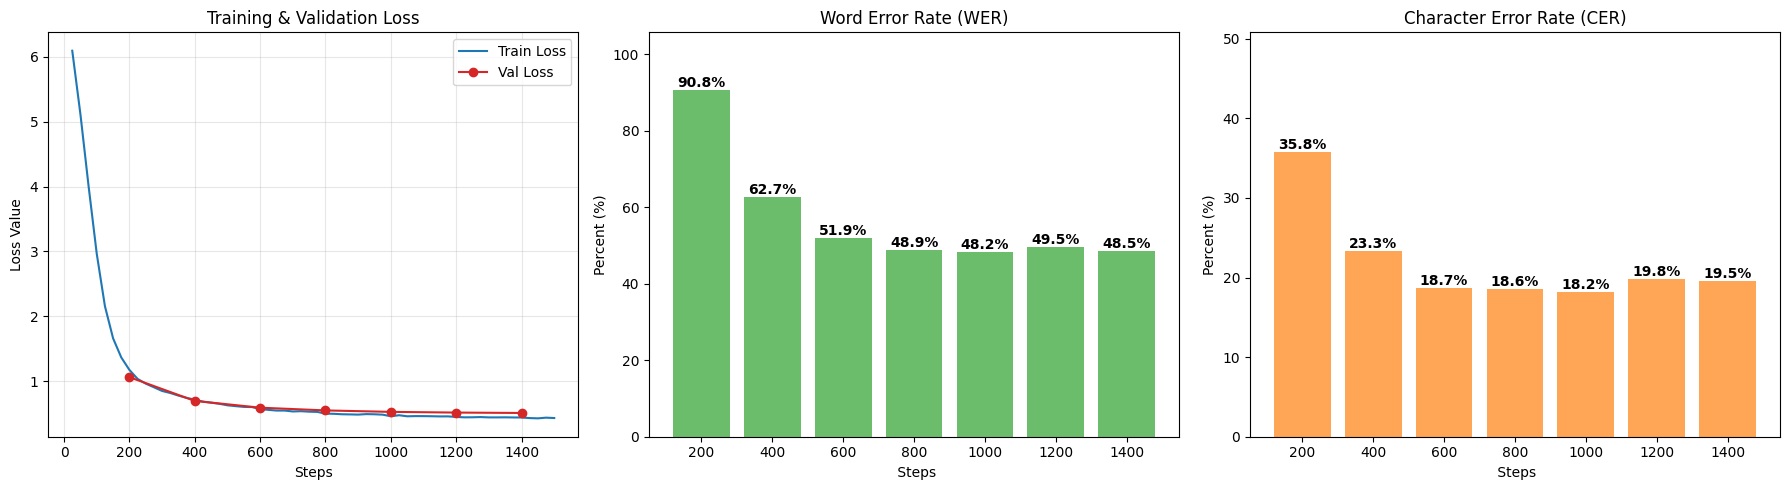

In [40]:
import matplotlib.pyplot as plt

# 1. Extracting logs
history = trainer.state.log_history
train_loss, train_steps = [], []
eval_loss, eval_steps = [], []
eval_wer, eval_cer = [], []

for entry in history:
    if "loss" in entry:
        train_loss.append(entry["loss"])
        train_steps.append(entry["step"])
    if "eval_loss" in entry:
        eval_loss.append(entry["eval_loss"])
        eval_steps.append(entry["step"])
        eval_wer.append(entry.get("eval_wer", 0))
        eval_cer.append(entry.get("eval_cer", 0))

# 2. Plotting - 3 Subplots in one row
plt.figure(figsize=(18, 5))

# --- Subplot 1: Loss ---
plt.subplot(1, 3, 1)
plt.plot(train_steps, train_loss, label="Train Loss", color="#1f77b4")
if eval_loss:
    plt.plot(eval_steps, eval_loss, label="Val Loss", marker='o', color="#d62728")
plt.title("Training & Validation Loss")
plt.xlabel("Steps")
plt.ylabel("Loss Value")
plt.legend()
plt.grid(True, alpha=0.3)

# --- Subplot 2: WER (Word Error Rate) ---
plt.subplot(1, 3, 2)
if eval_wer:
    bars_wer = plt.bar([str(s) for s in eval_steps], eval_wer, color="#2ca02c", alpha=0.7)
    plt.title("Word Error Rate (WER)")
    plt.ylabel("Percent (%)")
    plt.xlabel(" Steps")
    # Add values on top of bars
    for bar in bars_wer:
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), 
                 f'{bar.get_height():.1f}%', ha='center', va='bottom', fontweight='bold')
    plt.ylim(0, max(eval_wer) + 15)

# --- Subplot 3: CER (Character Error Rate) ---
plt.subplot(1, 3, 3)
if eval_cer:
    bars_cer = plt.bar([str(s) for s in eval_steps], eval_cer, color="#ff7f0e", alpha=0.7)
    plt.title("Character Error Rate (CER)")
    plt.ylabel("Percent (%)")
    plt.xlabel(" Steps")
    # Add values on top of bars
    for bar in bars_cer:
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), 
                 f'{bar.get_height():.1f}%', ha='center', va='bottom', fontweight='bold')
    plt.ylim(0, max(eval_cer) + 15)

plt.tight_layout()
plt.savefig("detailed_kikuyu_metrics.png")
plt.show()

In [29]:
# The the best model found during training
best_model_path = trainer.state.best_model_checkpoint
print(f"Your best model is saved at: {best_model_path}")

final_model_path = "./"

Your best model is saved at: ./checkpoint-1000


In [38]:
from transformers import pipeline
from IPython.display import Audio, display
import torch
model_path = "./checkpoint-1000"
pipe = pipeline(
    "automatic-speech-recognition",
    model=model_path,
    device=0 if torch.cuda.is_available() else -1,
)
pipe.model.config.forced_decoder_ids = None
pipe.model.generation_config.forced_decoder_ids = None

# Looping  through samples to display audio and text
for i in range(3):
    sample = test_ds[i]
    prediction = pipe(sample["audio"]["array"])
    
    print(f"\nSample {i+1} ")

    
    # Displaying  the audio player (Reference Audio)
    display(Audio(sample["audio"]["array"], rate=sample["audio"]["sampling_rate"]))
    print(f"Reference:  {sample['transcription']}")
    print(f"Prediction: {prediction['text']}")
    print("-" * 30)

Device set to use cuda:0



Sample 1 


Reference:  Andũ ethĩ nĩ makoretwo makĩremwo kũbanga ihinda rĩrĩa rĩagĩrĩire rĩa kũhũthĩra thimũ.
Prediction: andũ ethĩ nĩ makoretwo makĩrĩmwe kũbanga ihinda rĩrĩa rĩagĩrĩire rĩa kũhũthĩra thimũ
------------------------------

Sample 2 


Reference:  Ngwatanĩro ya kũhonokia andũ ya Mombatha ugĩte atĩ nĩ ĩhonoketie andũ magana mana ma mĩrongo ĩtano na ithatu, no makĩria ma ngiri ĩmwe marĩ ũgwati-inĩ.
Prediction: Ngwatanĩra ya kũhonokia andũ ya mombasa yugĩte atĩhonoketie andũ magana mana ma mĩrongo ĩtano na ithatũ no makĩria ma ngiri ĩmwe marĩ ũgwati-inĩ
------------------------------

Sample 3 


Reference:  Mũgitĩri ũcio wa mũbira wa Spain nĩ we ũgũtuĩka mũgitĩri wa mũbira wa goro mũno rĩrĩa agaathamĩra Ulinzi Stars.
Prediction: Mũgitĩrio cia wa mũbira wa Spain nĩwe ũgũtuĩka mũgitĩri wa mũbira wa ngoro mũno rĩrĩa agatha mĩra Ulinzi Stars
------------------------------
